# 02 — Pre-procesamiento reproducible

Valida el pipeline determinístico (resampling → clipping → z-score → crop hepático) sobre una muestra del dataset y materializa los tensores en `data/cache/` para acelerar los reentrenamientos.

Justificación detallada en `reports/02_methodology_crispmlq.md §Fase 2`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

from src.data.inventory import build_inventory
from src.data.transforms import build_preprocess, build_train_augment

DATA_ROOT = PROJECT_ROOT / 'data' / 'CirrMRI600plus_raw'
inventory = build_inventory(DATA_ROOT)
print('records:', len(inventory.records))

records: 738


In [2]:
preprocess = build_preprocess(out_spacing=(1.0, 1.0, 3.0), clip_percentiles=(0.5, 99.5))
augment = build_train_augment(rotation_deg=10.0, prob_flip_h=0.5, gaussian_noise_std=0.05)

rng = np.random.default_rng(11)
rec = rng.choice([r for r in inventory.records if r.mask_path is not None])
out = preprocess({'image': str(rec.image_path), 'mask': str(rec.mask_path)})
print('shape post-preprocess:', out['image'].shape, '| dtype:', out['image'].dtype)
out_aug = augment(out)
print('shape post-augment:', out_aug['image'].shape)

shape post-preprocess: torch.Size([1, 410, 333, 96]) | dtype: torch.float32
shape post-augment: torch.Size([1, 410, 333, 96])


C:\Users\Sebas\AppData\Local\Temp\ipykernel_24032\829077075.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); fig.show()


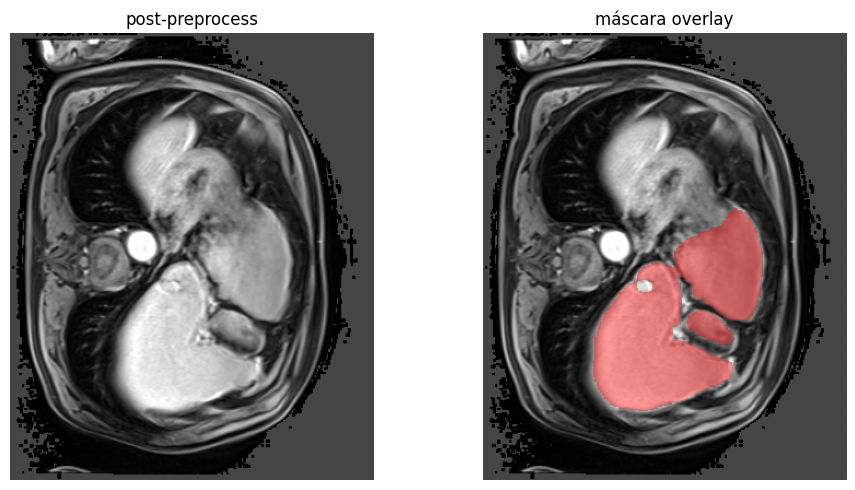

In [3]:
img = out['image'].numpy() if hasattr(out['image'], 'numpy') else np.asarray(out['image'])
msk = out['mask'].numpy() if hasattr(out['mask'], 'numpy') else np.asarray(out['mask'])
img = img[0]; msk = msk[0]
if msk.sum() > 0:
    z_with = np.unique(np.argwhere(msk > 0)[:, -1])
    z = int(np.median(z_with))
else:
    z = img.shape[-1] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img[..., z], cmap='gray'); axes[0].set_title('post-preprocess'); axes[0].axis('off')
axes[1].imshow(img[..., z], cmap='gray')
axes[1].imshow(np.ma.masked_where(msk[..., z] == 0, msk[..., z]), cmap='autumn', alpha=0.4)
axes[1].set_title('máscara overlay'); axes[1].axis('off')
fig.tight_layout(); fig.show()

## Sanity checks
1. La media post-z-score debe estar cerca de 0 y la std cerca de 1 (sobre voxeles no-cero).
2. El spacing del header NIfTI tras Spacingd debe ser (1.0, 1.0, 3.0).
3. La máscara post-resampling debe seguir siendo binaria (0/1).

In [4]:
v = img[img > 0]
print('mean:', v.mean(), 'std:', v.std())
print('unique values mask:', np.unique(msk))

mean: 1.0236939 std: 0.7786811
unique values mask: [0. 1.]
